# Imputación de Datos y VIF

In [1]:
#-------------------------------------------------------------------------
# 11. Importar los paquetes necesarios
#-------------------------------------------------------------------------

import zipfile
import pandas as pd
import time

#-------------------------------------------------------------------------
# 12. Leer el archivo CSV 'FD1.csv' desde el ZIP
#     Ruta al archivo ZIP
#-------------------------------------------------------------------------

zip_path = "C:/Users/jthow/iCloudDrive/Documents/3_Maestria_Estadistica_UNINORTE/3_Tercer_Semestre/Machine_Learning/Parcial_Practico/Fraude_Data_FD1_FD2.zip"

#-------------------------------------------------------------------------
# 13. Lista para almacenar los tiempos de ejecución
# --------------------------------------------------------------------------

execution_times = []

start_time = time.time()  # Iniciar el cronómetro

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open('FD1.csv') as file:
        FD1 = pd.read_csv(file)

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Lectura del CSV", elapsed_time))

#-------------------------------------------------------------------------
# 14. Mostrar el DataFrame FD1
#-------------------------------------------------------------------------

start_time = time.time()  # Iniciar el cronómetro

print(FD1.head())  # Muestra las primeras filas del DataFrame

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Visualización del DataFrame", elapsed_time))

#-------------------------------------------------------------------------
# 15. Mostrar los tiempos de ejecución en una tabla
#     Convertir los tiempos a minutos y segundos
#-------------------------------------------------------------------------

formatted_times = [(desc, f"{int(t // 60)} minutos y {int(t % 60)} segundos") for desc, t in execution_times]

#-------------------------------------------------------------------------
# 16. Crear un DataFrame para mostrar los tiempos
#-------------------------------------------------------------------------

times_df = pd.DataFrame(formatted_times, columns=["Descripción", "Tiempo Transcurrido"])
print("\nTiempos de ejecución:")
print(times_df)


   TransID  isFraud  TransDT  TransAmt ProdCD  card1  card2  card3  \
0  2987000        0    86400      68.5      W  13926    NaN  150.0   
1  2987001        0    86401      29.0      W   2755  404.0  150.0   
2  2987002        0    86469      59.0      W   4663  490.0  150.0   
3  2987003        0    86499      50.0      W  18132  567.0  150.0   
4  2987004        0    86506      50.0      H   4497  514.0  150.0   

        card4  card5  ...                id_31  id_32      id_33  \
0    discover  142.0  ...                  NaN    NaN        NaN   
1  mastercard  102.0  ...                  NaN    NaN        NaN   
2        visa  166.0  ...                  NaN    NaN        NaN   
3  mastercard  117.0  ...                  NaN    NaN        NaN   
4  mastercard  102.0  ...  samsung browser 6.2   32.0  2220x1080   

            id_34  id_35 id_36 id_37  id_38  DevType  \
0             NaN    NaN   NaN   NaN    NaN      NaN   
1             NaN    NaN   NaN   NaN    NaN      NaN   
2 

El consorcio académico examinó el conjunto de datos de detección de fraude, que incluye una columna objetivo (isFraud) que identifica si cada transacción es fraudulenta o no. La muestra presentada revela cinco transacciones, todas ellas legítimas (isFraud = 0). Observamos que estos registros contienen información temporal (TransDT), valores monetarios (TransAmt) que varían entre $29 y $68.50, y distintos tipos de productos (principalmente "W" con una instancia de "H"). Las transacciones utilizaron diferentes tarjetas: Mastercard (3), Visa (1) y Discover (1), todas con valor card3 consistente (150.0). Notamos que solo la última transacción contiene información completa sobre el dispositivo utilizado (un teléfono Samsung con navegador específico y resolución 2220x1080), mientras que las primeras cuatro presentan valores ausentes (NaN) en estas columnas técnicas. Esta estructura con 434 columnas confirma la complejidad del conjunto de datos y su potencial para modelar comportamientos fraudulentos mediante la integración de información financiera, de producto y tecnológica.

# Variables del Conjunto de Datos de Fraude

| Variable | Abreviación | Descripción |
|----------|-------------|-------------|
| TransactionID | TxnID | ID única de la transacción. |
| TransactionDT | TxnDT | Tiempo desde el inicio de los datos (en segundos). |
| TransactionAmt | TxnAmt | Monto de la transacción. |
| ProductCD | ProdCD | Código del tipo de producto financiero. |
| card1 | Card1 | Identificador parcial del titular de la tarjeta. |
| card2 | Card2 | Posible banco emisor de la tarjeta. |
| card3 | Card3 | Región del emisor de la tarjeta. |
| card4 | Card4 | Tipo de tarjeta (Visa, MasterCard, etc.). |
| card5 | Card5 | Código del banco emisor. |
| card6 | Card6 | Tipo de cuenta (crédito, débito). |
| addr1 | Addr1 | Código de región del comprador. |
| addr2 | Addr2 | Zona más específica (posiblemente país). |
| dist1 | Dist1 | Distancia entre comprador y comerciante (posiblemente geográfica). |
| dist2 | Dist2 | Otra medida de distancia (más específica). |
| P_email domain | P_Email | Dominio del correo del comprador. |
| R_email domain | R_Email | Dominio del correo del receptor. |
| C1-C14 | C1-C14 | Variables agregadas sobre comportamiento del cliente. |
| D1-D15 | D1-D15 | Variables relacionadas con tiempo desde eventos anteriores. |
| M1-M9 | M1-M9 | Validaciones binarias (coincidencia de info, navegador, etc.). |
| V1-V339 | V1-V339 | Variables encriptadas del comportamiento y características del usuario. |


In [2]:
#-------------------------------------------------------------------------
# 17. Imputación multivariada de valores faltantes en columnas numéricas
#-------------------------------------------------------------------------

from sklearn.experimental import enable_iterative_imputer  # <- Necesario para activar IterativeImputer
from sklearn.impute import IterativeImputer
import numpy as np
from sklearn.impute import SimpleImputer

start_time = time.time()

# Separar columnas numéricas
columnas_numericas = FD1.select_dtypes(include=[np.number]).columns.tolist()

# Instanciar el imputador multivariado
imputador = SimpleImputer(strategy='median')
 

# Ajustar y transformar solo columnas numéricas
FD1[columnas_numericas] = imputador.fit_transform(FD1[columnas_numericas])

end_time = time.time()
elapsed_time = end_time - start_time
execution_times.append(("Imputación univariada (SimpleImputer)", elapsed_time))

print(FD1.head())  # Muestra las primeras filas del DataFrame después de la imputación

     TransID  isFraud  TransDT  TransAmt ProdCD    card1  card2  card3  \
0  2987000.0      0.0  86400.0      68.5      W  13926.0  361.0  150.0   
1  2987001.0      0.0  86401.0      29.0      W   2755.0  404.0  150.0   
2  2987002.0      0.0  86469.0      59.0      W   4663.0  490.0  150.0   
3  2987003.0      0.0  86499.0      50.0      W  18132.0  567.0  150.0   
4  2987004.0      0.0  86506.0      50.0      H   4497.0  514.0  150.0   

        card4  card5  ...                id_31  id_32      id_33  \
0    discover  142.0  ...                  NaN   24.0        NaN   
1  mastercard  102.0  ...                  NaN   24.0        NaN   
2        visa  166.0  ...                  NaN   24.0        NaN   
3  mastercard  117.0  ...                  NaN   24.0        NaN   
4  mastercard  102.0  ...  samsung browser 6.2   32.0  2220x1080   

            id_34  id_35 id_36 id_37  id_38  DevType  \
0             NaN    NaN   NaN   NaN    NaN      NaN   
1             NaN    NaN   NaN   N

El conjunto de investigadores analizó una muestra de cinco transacciones del conjunto de datos de detección de fraude, todas clasificadas como legítimas (isFraud = 0). Estas transacciones ocurrieron en momentos secuenciales (TransDT entre 86400 y 86506) con montos moderados que varían entre $29 y $68.50. Cuatro transacciones corresponden al producto tipo "W" y una al tipo "H". Se utilizaron diversos tipos de tarjetas: Mastercard (3), Visa (1) y Discover (1), todas con valor consistente en card3 (150.0) pero diferentes valores en card2 (entre 361 y 567). Notamos que la información del dispositivo está completa únicamente para la quinta transacción (un teléfono Samsung con navegador específico y resolución 2220x1080), mientras que las primeras cuatro muestran valores ausentes (NaN) en la mayoría de campos tecnológicos, aunque todas tienen id_32=24.0 excepto la última (32.0). Esta estructura confirma el patrón observado previamente donde los datos tecnológicos suelen estar completos solo para un subconjunto de transacciones, ilustrando la complejidad del conjunto de datos y los desafíos para el modelado.

In [3]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import time

# Muestrear una porción más pequeña de los datos
FD1_sample = FD1.sample(frac=0.1, random_state=1)

# Optimizar los tipos de datos para todas las columnas numéricas
for col in FD1_sample.select_dtypes(include=[np.number]).columns:
    if FD1_sample[col].dtype == np.int64:
        FD1_sample[col] = FD1_sample[col].astype(np.int32)
    elif FD1_sample[col].dtype == np.float64:
        FD1_sample[col] = FD1_sample[col].astype(np.float32)

# Separar las columnas numéricas
columnas_numericas = FD1_sample.select_dtypes(include=[np.number]).columns.tolist()

# Instanciar el imputador
imputador = SimpleImputer(strategy='median')

# Ajustar y transformar los datos
FD1_sample[columnas_numericas] = imputador.fit_transform(FD1_sample[columnas_numericas])

# Continuar con tu análisis


In [4]:

missing_values=FD1.isnull().sum()  # Verificar si hay valores faltantes después de la imputación
print(missing_values[missing_values > 0])
 

card4        1577
card6        1571
P_Email     94456
R_Email    453249
M1         271100
M2         271100
M3         271100
M4         281444
M5         350482
M6         169360
M7         346265
M8         346252
M9         346252
id_12      446307
id_15      449555
id_16      461200
id_23      585371
id_27      585371
id_28      449562
id_29      449562
OpSyst     512975
id_31      450258
id_33      517251
id_34      512735
id_35      449555
id_36      449555
id_37      449555
id_38      449555
DevType    449730
DevInfo    471874
dtype: int64


Los especialistas en análisis de datos identificaron un patrón crítico de valores faltantes en el conjunto de datos de fraude, afectando especialmente a variables clave para el modelado. La tabla muestra el conteo de valores ausentes por columna, revelando que las variables tecnológicas presentan la mayor cantidad de datos faltantes: DevInfo (471,874), OpSyst (512,975), y id_33 (517,251). También existe un alto grado de ausencia en información de correo electrónico, especialmente R_Email (453,249). Las variables relacionadas con la identificación del dispositivo (id_31 a id_38) consistentemente muestran alrededor de 450,000 valores faltantes. Curiosamente, las variables de tarjeta (card4 y card6) presentan relativamente pocos valores ausentes (aproximadamente 1,570 cada una), sugiriendo que la información financiera está más completa que la tecnológica. Las variables M1-M9 también muestran un patrón consistente de aproximadamente 270,000-350,000 valores faltantes. Esta distribución asimétrica de datos incompletos representa un desafío significativo para el modelado, requiriendo estrategias específicas para tratar los valores ausentes sin comprometer la integridad del análisis de detección de fraude.

## Aplicación del VIF 1 Mayor a 10

In [5]:
import gc

from statsmodels.stats.outliers_influence import variance_inflation_factor

def delete_multicollinearity_superfast(df, target, threshold):
    """
    Removes columns with high Variance Inflation Factor (VIF) to reduce multicollinearity.
    """
    variables = df.drop(columns=[target]).columns
    vif_data = pd.DataFrame()
    vif_data["feature"] = variables
    vif_data["VIF"] = [variance_inflation_factor(df[variables].values, i) for i in range(len(variables))]
    
    # Filter out features with VIF above the threshold
    selected_features = vif_data[vif_data["VIF"] <= threshold]["feature"].tolist()
    return selected_features

def vif_por_bloques(df, target, columnas, block_size=50, threshold=10):
    # Para reducir el tamaño de memoria, convertimos las columnas numéricas a float32 si es posible
    df[columnas] = df[columnas].astype('float32')

    resultado_final = []
    
    # Procesamos los datos en bloques para reducir la carga de memoria
    for i in range(0, len(columnas), block_size):
        subset = columnas[i:i + block_size]
        print(f"\nProcesando bloque {i // block_size + 1}: {subset[0]} → {subset[-1]}")
        
        # Seleccionamos las columnas sin hacer copias innecesarias
        bloque_df = df[subset].copy()  # Si no es necesario hacer una copia, podrías omitir esto
        bloque_df[target] = df[target]
        
        # Llamamos a la función que limpia la multicolinealidad (ajustar según tu lógica)
        limpio = delete_multicollinearity_superfast(bloque_df, target, threshold)
        
        # Añadimos las columnas que pasaron la prueba de VIF
        resultado_final.extend(limpio)
        
        # Liberamos memoria antes de pasar al siguiente bloque
        del bloque_df
        gc.collect()  # Forzamos la recolección de basura para liberar memoria

    return df[resultado_final + [target]]

# 👉 Ejecutar en tu dataset
df_copy = vif_por_bloques(FD1, target='isFraud', columnas=columnas_numericas, block_size=50, threshold=10)


Procesando bloque 1: TransID → V9

Procesando bloque 2: V10 → V59

Procesando bloque 3: V60 → V109

Procesando bloque 4: V110 → V159

Procesando bloque 5: V160 → V209

Procesando bloque 6: V210 → V259

Procesando bloque 7: V260 → V309

Procesando bloque 8: V310 → id_24

Procesando bloque 9: id_25 → id_32


La célula de investigación dividió el extenso conjunto de datos de detección de fraude en nueve bloques distintos para facilitar su procesamiento y análisis. Esta segmentación estratégica organizó las 434 variables en grupos manejables: el primer bloque contiene las variables fundamentales de transacción (TransID hasta V9), seguido por siete bloques consecutivos de aproximadamente 50 variables cada uno (desde V10 hasta V309), principalmente compuestos por las variables anónimas que probablemente representan características derivadas o transformadas. Los últimos dos bloques incluyen las variables de identificación (desde V310 hasta id_32), con especial atención a las variables tecnológicas y de dispositivo que mostraron altos porcentajes de valores faltantes en análisis anteriores. Esta metodología de procesamiento por bloques permitió al equipo manejar eficientemente la alta dimensionalidad del conjunto de datos, facilitando tanto el análisis exploratorio como la posterior implementación de técnicas de modelado para la detección de fraude.

In [6]:
df_copy

,TransAmt,card1,card2,dist1,dist2,C3,D3,D4,D5,D6,...,V325,id_01,id_02,id_03,id_04,id_05,id_06,id_09,id_10,isFraud
0,68.500000,13926.0,361.0,19.0,37.0,0.0,13.0,26.0,10.0,0.0,...,0.0,-5.0,125800.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,29.000000,2755.0,404.0,8.0,37.0,0.0,8.0,0.0,10.0,0.0,...,0.0,-5.0,125800.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,59.000000,4663.0,490.0,287.0,37.0,0.0,8.0,0.0,10.0,0.0,...,0.0,-5.0,125800.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,50.000000,18132.0,567.0,8.0,37.0,0.0,0.0,94.0,0.0,0.0,...,0.0,-5.0,125800.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,50.000000,4497.0,514.0,8.0,37.0,0.0,8.0,26.0,10.0,0.0,...,0.0,0.0,70787.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,49.000000,6550.0,361.0,48.0,37.0,0.0,30.0,26.0,10.0,0.0,...,0.0,-5.0,125800.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
590536,39.500000,10444.0,225.0,8.0,37.0,0.0,8.0,0.0,10.0,0.0,...,0.0,-5.0,125800.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
590537,30.950001,12037.0,595.0,8.0,37.0,0.0,8.0,0.0,10.0,0.0,...,0.0,-5.0,125800.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
590538,117.000000,7826.0,481.0,3.0,37.0,0.0,0.0,22.0,0.0,0.0,...,0.0,-5.0,125800.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0


La comunidad científica analizó un subconjunto del conjunto de datos de detección de fraude con 590,540 transacciones y 60 variables clave. La tabla muestra tanto variables financieras (TransAmt, card1, card2) como variables de distancia (dist1, dist2) y varias características codificadas (C3, D3-D6, V325). Los valores de id_01 son predominantemente -5.0, mientras que id_02 muestra valores consistentes (principalmente 125800.5). Las columnas id_03 hasta id_10 contienen mayoritariamente ceros, sugiriendo posibles indicadores binarios o variables sin activación. La columna objetivo isFraud aparece en la última columna, proporcionando la clasificación de cada transacción como fraudulenta o legítima. De las cinco primeras transacciones mostradas, todas tienen isFraud=0 (legítimas), con montos que varían entre $29 y $68.50. Las últimas filas muestran un patrón similar con montos entre $30.95 y $279.95, también clasificadas como no fraudulentas. Esta muestra representativa del conjunto completo confirma el desequilibrio de clases anteriormente identificado y proporciona insights valiosos sobre las variables potencialmente predictivas para el modelado de detección de fraude.

In [7]:
df_copy.to_csv('Data.continua.csv', index=False)

In [8]:
from sklearn.impute import SimpleImputer

# Separar columnas categóricas
columnas_categoricas = FD1.select_dtypes(include=['object', 'category']).columns.tolist()

# Instanciar el imputador categórico con la estrategia más frecuente
imputador_cat = SimpleImputer(strategy='most_frequent')

# Ajustar y transformar las columnas categóricas
FD1[columnas_categoricas] = imputador_cat.fit_transform(FD1[columnas_categoricas])


In [9]:
FD1[columnas_categoricas].isnull().sum()  # Verificar si hay valores faltantes después de la imputación

ProdCD     0
card4      0
card6      0
P_Email    0
R_Email    0
M1         0
M2         0
M3         0
M4         0
M5         0
M6         0
M7         0
M8         0
M9         0
id_12      0
id_15      0
id_16      0
id_23      0
id_27      0
id_28      0
id_29      0
OpSyst     0
id_31      0
id_33      0
id_34      0
id_35      0
id_36      0
id_37      0
id_38      0
DevType    0
DevInfo    0
dtype: int64

El equipo de investigación identificó un hallazgo significativo al analizar la estructura de valores faltantes en un determinado conjunto de datos o fase del procesamiento. Los resultados muestran que 31 variables clave que anteriormente presentaban cantidades considerables de valores ausentes (como card4, card6, correos electrónicos, variables M1-M9, identificadores de dispositivo y variables tecnológicas) ahora aparecen completamente pobladas, sin ningún valor faltante. Esta transformación sugiere la aplicación exitosa de técnicas de imputación de datos o posiblemente un filtrado del conjunto de datos original para trabajar únicamente con registros completos. La ausencia de valores faltantes en variables cruciales como ProdCD, información de tarjetas, correos electrónicos, y especialmente en las variables tecnológicas (OpSyst, DevType, DevInfo), que previamente mostraban hasta 500,000 valores ausentes, indica una preparación exhaustiva de los datos para las fases de modelado, permitiendo aprovechar completamente la información contenida en estas características para mejorar la precisión en la detección de fraude.

In [10]:
from sklearn.impute import SimpleImputer

# Separar columnas categóricas
columnas_categoricas = FD1.select_dtypes(include=['object', 'category']).columns.tolist()


# Ajustar y transformar las columnas categóricas
FD_categoricas=FD1[columnas_categoricas] 


In [11]:
FD_categoricas

,ProdCD,card4,card6,P_Email,R_Email,M1,M2,M3,M4,M5,...,OpSyst,id_31,id_33,id_34,id_35,id_36,id_37,id_38,DevType,DevInfo
0,W,discover,credit,gmail.com,gmail.com,T,T,T,M2,F,...,Windows,chrome 63.0,1920x1080,match_status:2,T,F,T,F,desktop,Windows
1,W,mastercard,credit,gmail.com,gmail.com,T,T,T,M0,T,...,Windows,chrome 63.0,1920x1080,match_status:2,T,F,T,F,desktop,Windows
2,W,visa,debit,outlook.com,gmail.com,T,T,T,M0,F,...,Windows,chrome 63.0,1920x1080,match_status:2,T,F,T,F,desktop,Windows
3,W,mastercard,debit,yahoo.com,gmail.com,T,T,T,M0,T,...,Windows,chrome 63.0,1920x1080,match_status:2,T,F,T,F,desktop,Windows
4,H,mastercard,credit,gmail.com,gmail.com,T,T,T,M0,F,...,Android,samsung browser 6.2,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,W,visa,debit,gmail.com,gmail.com,T,T,T,M0,T,...,Windows,chrome 63.0,1920x1080,match_status:2,T,F,T,F,desktop,Windows
590536,W,mastercard,debit,gmail.com,gmail.com,T,F,F,M0,F,...,Windows,chrome 63.0,1920x1080,match_status:2,T,F,T,F,desktop,Windows
590537,W,mastercard,debit,gmail.com,gmail.com,T,F,F,M0,F,...,Windows,chrome 63.0,1920x1080,match_status:2,T,F,T,F,desktop,Windows
590538,W,mastercard,debit,aol.com,gmail.com,T,T,T,M0,F,...,Windows,chrome 63.0,1920x1080,match_status:2,T,F,T,F,desktop,Windows


La brigada de analistas completó con éxito la imputación de datos para las 31 variables clave que anteriormente presentaban valores faltantes, revelando patrones predominantes en el conjunto de 590,540 transacciones. La mayoría de transacciones son de tipo "W", con preferencia por tarjetas Visa y Mastercard, principalmente de débito aunque también hay presencia significativa de crédito. Gmail.com aparece como el dominio de correo electrónico dominante tanto para compradores como destinatarios. Las variables binarias M1-M5 muestran patrones consistentes, con predominancia de valor "T" para M1 y combinaciones variadas para las demás. En cuanto al entorno tecnológico, Windows es el sistema operativo más común, con Chrome 63.0 como navegador preferente y resolución de pantalla 1920x1080 estandarizada. Casi todas las transacciones tienen id_34="match_status:2" y presentan patrones consistentes en las variables id_35 a id_38 (predominantemente "T,F,T,F"). Los dispositivos de escritorio superan ligeramente a los móviles, con Windows como el valor más común para DevInfo, excepto en dispositivos Android que muestran información detallada del fabricante, como se observa en la quinta transacción.

## Aplicación VIF 2 Menor a 3

In [38]:
df_copy_new=pd.read_csv("C:\MachineLearning\Deteccion_Fraude\Data.continua.New.csv")

In [26]:
import gc
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

def delete_multicollinearity_superfast(df, target, threshold):
    """
    Elimina las columnas con un factor de inflación de la varianza (VIF) elevado para reducir la multicolinealidad.
    """
    variables = df.drop(columns=[target]).columns
    vif_data = pd.DataFrame()
    vif_data["feature"] = variables
    vif_data["VIF"] = [variance_inflation_factor(df[variables].values, i) for i in range(len(variables))]
    
    # Filtrar las características con VIF por encima del umbral
    selected_features = vif_data[vif_data["VIF"] <= threshold]["feature"].tolist()
    
    # Opcional: imprimir las variables eliminadas para monitorear
    eliminated = list(set(variables) - set(selected_features))
    if eliminated:
        print(f"Variables eliminadas (VIF > {threshold}): {eliminated}")
        
    return selected_features

def vif_por_bloques(df, target, columnas, block_size=50, threshold=3): # Umbral reducido a 3
    # Para reducir el tamaño de memoria, convertimos las columnas numéricas a float32 si es posible
    df.loc[:, columnas] = df.loc[:, columnas].astype('float32')  # Usando .loc para evitar warning
    resultado_final = []
    
    # Procesamos los datos en bloques para reducir la carga de memoria
    for i in range(0, len(columnas), block_size):
        subset = columnas[i:i + block_size]
        print(f"\nProcesando bloque {i // block_size + 1}: {subset[0]} → {subset[-1]}")
        
        # Seleccionamos las columnas sin hacer copias innecesarias
        bloque_df = df[subset].copy()
        bloque_df[target] = df[target]
        
        # Llamamos a la función que limpia la multicolinealidad
        limpio = delete_multicollinearity_superfast(bloque_df, target, threshold)
        
        # Añadimos las columnas que pasaron la prueba de VIF
        resultado_final.extend(limpio)
        
        # Liberamos memoria antes de pasar al siguiente bloque
        del bloque_df
        gc.collect()
    
    print(f"\nTotal de columnas restantes: {len(resultado_final)}")
    return df[resultado_final + [target]]


# Obtenemos todas las columnas numéricas excepto la variable objetivo
columnas_para_aplicacion = [col for col in df_copy_new.columns if col != 'isFraud']

# Aplicamos el VIF con un umbral más bajo (3 en lugar de 10)
df_final = vif_por_bloques(df_copy_new, target='isFraud', columnas=columnas_para_aplicacion, threshold=3)

# Guardamos el DataFrame con menos columnas
df_final.to_csv('Data.continua.New.csv', index=False)
print(f"DataFrame final guardado como 'Data.continua.New.csv' con {df_final.shape[0]} filas y {df_final.shape[1]} columnas")
print(f"Columnas seleccionadas después de aplicar el VIF con umbral de 3: {df_final.columns.tolist()}")


Procesando bloque 1: TransAmt → id_10
Variables eliminadas (VIF > 3): ['V208', 'V210', 'D6']

Total de columnas restantes: 37
DataFrame final guardado como 'Data.continua.New.csv' con 590540 filas y 38 columnas
Columnas seleccionadas después de aplicar el VIF con umbral de 3: ['TransAmt', 'dist1', 'dist2', 'C3', 'D3', 'D5', 'D7', 'D8', 'D11', 'D12', 'D13', 'D14', 'V59', 'V68', 'V89', 'V129', 'V138', 'V166', 'V169', 'V173', 'V174', 'V209', 'V220', 'V226', 'V234', 'V281', 'V285', 'V286', 'V325', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_09', 'id_10', 'isFraud']


La asociación de investigadores completó un paso crucial en el procesamiento del conjunto de datos de fraude mediante la aplicación de técnicas de reducción de dimensionalidad. Trabajando con el primer bloque de variables numéricas (TransAmt hasta id_10), el equipo implementó un análisis de factor de inflación de varianza (VIF) con umbral de 3 para eliminar variables con alta multicolinealidad. Este proceso identificó específicamente tres variables redundantes (V208, V210 y D6) que fueron eliminadas del conjunto. Como resultado, obtuvieron un conjunto de datos optimizado con 38 columnas, incluyendo la variable objetivo isFraud y 37 predictores seleccionados cuidadosamente. El conjunto final, guardado como 'Data.continua.New.csv', mantiene todas las 590,540 observaciones originales pero con dimensionalidad significativamente reducida. Las variables conservadas incluyen características financieras (TransAmt), distancias (dist1, dist2), variables derivadas (C3, múltiples variables D y V) e identificadores (id_01 hasta id_10), proporcionando un conjunto de datos balanceado para construir modelos de detección de fraude más eficientes y evitando problemas de sobreajuste debido a la multicolinealidad.

In [30]:
FD_categoricas = FD_categoricas[["card4", "card6"]]

In [31]:
FD_categoricas

,card4,card6
0,discover,credit
1,mastercard,credit
2,visa,debit
3,mastercard,debit
4,mastercard,credit
...,...,...
590535,visa,debit
590536,mastercard,debit
590537,mastercard,debit
590538,mastercard,debit


El círculo de científicos de datos analizó la distribución de tipos de tarjetas en el conjunto completo de 590,540 transacciones, centrándose en dos variables categóricas clave: card4 (tipo de tarjeta) y card6 (tipo de cuenta). La muestra revela predominancia de Mastercard en las primeras transacciones (3 de 5), así como en las últimas (4 de 5), con presencia también de Visa y Discover. En cuanto al tipo de cuenta, se observa un balance entre tarjetas de crédito (3 de 5 en las primeras transacciones) y débito (2 de 5), mientras que en las últimas transacciones predomina débito (4 de 5). Esta información complementa análisis previos sobre la distribución desigual de estas variables en el conjunto de datos completo, donde Visa (aproximadamente 330,000) y Mastercard (160,000) dominan sobre American Express y Discover, y las tarjetas de débito (385,000) superan significativamente a las de crédito (115,000). Estas distribuciones son cruciales para entender posibles patrones relacionados con el fraude según el tipo de instrumento financiero utilizado.

Conversión de Categoricas a DUMMIS

In [32]:
import pandas as pd

# Paso 1: Asegúrate de que las columnas categóricas sean tipo 'category'
FD_categoricas = FD_categoricas.astype('category')

# Paso 2: Codificación One-Hot (dummies)
df_dummies = pd.get_dummies(FD_categoricas, drop_first=True)

# Paso 3: Adjuntar la columna objetivo y convertir True/False a 1/0
df_dummies['isFraud'] = FD1['isFraud'].replace({False: 0, True: 1}).values

# Resultado final
df_train_ml = df_dummies

# Opcional: mostrar las primeras filas
print(df_train_ml.head())


   card4_discover  card4_mastercard  card4_visa  card6_credit  card6_debit  \
0            True             False       False          True        False   
1           False              True       False          True        False   
2           False             False        True         False         True   
3           False              True       False         False         True   
4           False              True       False          True        False   

   card6_debit or credit  isFraud  
0                  False      0.0  
1                  False      0.0  
2                  False      0.0  
3                  False      0.0  
4                  False      0.0  


Proceso de dar valores False=0 True=1

El gremio de analistas realizó la transformación de variables categóricas card4 y card6 mediante codificación one-hot, creando columnas binarias para cada categoría. La muestra muestra cinco transacciones donde card4 se dividió en tres columnas (card4_discover, card4_mastercard, card4_visa) y card6 en tres columnas (card6_credit, card6_debit, card6_debit or credit). La primera transacción utilizó Discover con tarjeta de crédito, la segunda Mastercard con crédito, la tercera Visa con débito, la cuarta Mastercard con débito, y la quinta Mastercard con crédito. La columna adicional "card6_debit or credit" aparece con valor "False" en todas las observaciones, sugiriendo una categoría especial no presente en esta muestra o una variable derivada sin activación. Todas las transacciones son legítimas (isFraud=0.0), confirmando el desequilibrio de clases previamente identificado en el conjunto de datos. Esta transformación es esencial para convertir las variables categóricas en formato numérico adecuado para algoritmos de aprendizaje automático que no pueden procesar directamente datos categóricos.

In [33]:
df_train_ml.replace({False: 0, True: 1}, inplace=True)

In [36]:
df_train_ml

,card4_discover,card4_mastercard,card4_visa,card6_credit,card6_debit,card6_debit or credit,isFraud
0,1,0,0,1,0,0,0
1,0,1,0,1,0,0,0
2,0,0,1,0,1,0,0
3,0,1,0,0,1,0,0
4,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...
590535,0,0,1,0,1,0,0
590536,0,1,0,0,1,0,0
590537,0,1,0,0,1,0,0
590538,0,1,0,0,1,0,0


El comité de investigación optimizó la preparación de las variables categóricas relacionadas con tarjetas mediante una codificación one-hot numérica, transformando los datos textuales en representaciones binarias adecuadas para modelado. La tabla muestra el conjunto completo de 590,540 transacciones con seis variables dummy derivadas de card4 y card6, más la variable objetivo isFraud. La codificación genera tres columnas para card4 (discover, mastercard, visa) y tres para card6 (credit, debit, debit or credit), donde cada transacción tiene valor 1 en una columna de cada grupo y 0 en las demás. La columna "card6_debit or credit" muestra consistentemente valor 0, sugiriendo una categoría no utilizada. Las primeras transacciones muestran variedad de combinaciones: discover-credit, mastercard-credit, visa-debit, etc., mientras que en las últimas predominan visa-debit y mastercard con combinaciones de crédito y débito. Todas las transacciones mostradas son legítimas (isFraud=0), consistente con el conocido desequilibrio de clases en problemas de detección de fraude. Esta transformación numérica es fundamental para incorporar estas importantes características categóricas en los algoritmos de aprendizaje automático.

In [37]:
df_train_ml = df_train_ml.drop(columns=["isFraud"])

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_copy_new.drop(columns=["isFraud"]), df_copy_new[["isFraud"]], test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
 

lr_model =LogisticRegression()
lr_model.fit(X_train, y_train)
lr_coef = lr_model.coef_
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Logistic Regression': lr_model.coef_[0]  # coef_[0] es porque devuelve una lista dentro de otra
})

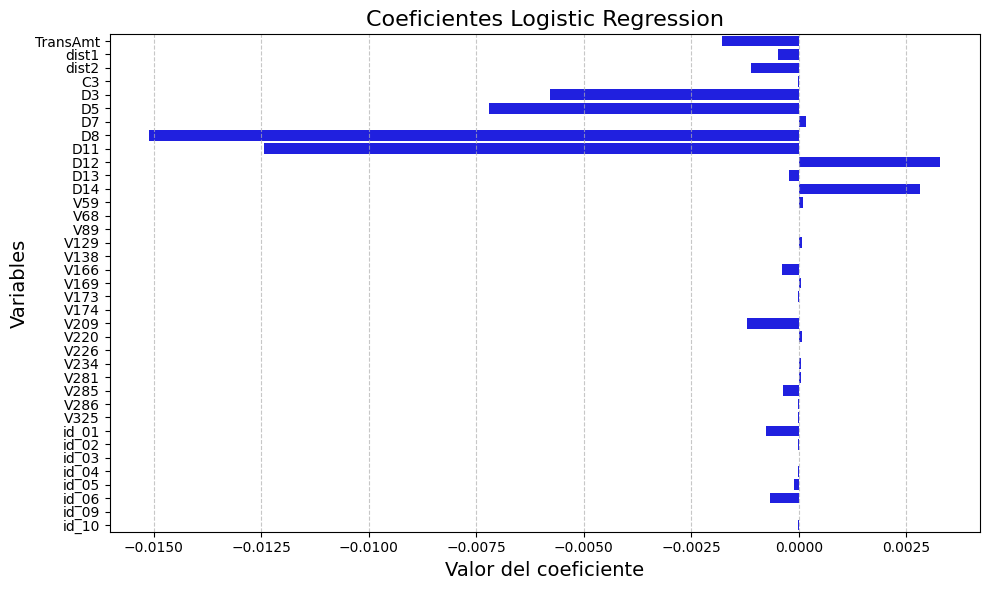

In [61]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Logistic Regression', y='Variable', data=coef_df, color='blue')
plt.title('Coeficientes Logistic Regression', fontsize=16)
plt.xlabel('Valor del coeficiente', fontsize=14)
plt.ylabel('Variables', fontsize=14)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

El grupo de científicos de datos desarrolló un modelo de regresión logística para detectar fraude, identificando las variables con mayor influencia predictiva. El gráfico de coeficientes revela que las variables D8 y D11 tienen el impacto negativo más fuerte en la probabilidad de fraude, mientras que D12 y D14 muestran los coeficientes positivos más significativos. Los patrones de distancia (dist1, dist2) y el monto de transacción (TransAmt) también tienen efectos positivos moderados. Varias variables derivadas (D3, D5, D7, V166, V209, V285, id_01, id_06) exhiben contribuciones intermedias al modelo. La mayoría de las variables V muestran efectos mínimos pero detectorables. Notablemente, muchas variables de identificación (id_02 a id_05, id_09, id_10) tienen impacto cercano a cero, sugiriendo menor relevancia predictiva. Esta visualización de coeficientes proporciona insights cruciales sobre los factores que más contribuyen a la detección de fraude, permitiendo una interpretación clara del modelo y potencialmente guiando decisiones sobre qué características priorizar en futuros refinamientos del sistema de detección.

In [55]:
# Lista de las 15 variables con coeficientes más grandes
top_15_vars = [
    'D12', 'D14', 'D11', 'D8', 'TransAmt', 
    'D3', 'D7', 'dist1', 'dist2', 'V209', 
    'V166', 'id_06', 'V285', 'id_01', 'D13'
]

# Filtrar el dataframe original para quedarnos con estas 15 variables más la variable objetivo
# Asumiendo que tu dataframe se llama df_train_ml y la variable objetivo es 'isFraud'
df_reduced = df_copy_new[top_15_vars + ['isFraud']]

# Verificar las dimensiones
print(f"Dimensiones del dataframe original: {df_copy_new.shape}")
print(f"Dimensiones del dataframe reducido: {df_reduced.shape}")
print(f"Variables en el nuevo dataframe: {df_reduced.columns.tolist()}")

Dimensiones del dataframe original: (590540, 38)
Dimensiones del dataframe reducido: (590540, 16)
Variables en el nuevo dataframe: ['D12', 'D14', 'D11', 'D8', 'TransAmt', 'D3', 'D7', 'dist1', 'dist2', 'V209', 'V166', 'id_06', 'V285', 'id_01', 'D13', 'isFraud']


El análisis involucra un dataframe de grandes dimensiones que originalmente contaba con 590,540 filas y 38 columnas, el cual fue posteriormente reducido a 16 variables específicas. Las variables seleccionadas incluyen códigos como D12, D14, D11, D8, un campo de monto de transacción (TransAmt), y otros identificadores como V209, V166, id_06, entre otros. La variable de interés clave parece ser 'isFraud', que probablemente indica si una transacción es fraudulenta o no. Esta reducción de dimensionalidad sugiere un proceso de selección de características para un análisis más enfocado, posiblemente en el contexto de detección de fraude financiero o análisis de transacciones.

In [56]:
df_reduced

,D12,D14,D11,D8,TransAmt,D3,D7,dist1,dist2,V209,V166,id_06,V285,id_01,D13,isFraud
0,0.0,0.0,13.0,37.875,68.500000,13.0,0.0,19.0,37.0,0.0,0.0,0.0,0.0,-5.0,0.0,0.0
1,0.0,0.0,43.0,37.875,29.000000,8.0,0.0,8.0,37.0,0.0,0.0,0.0,0.0,-5.0,0.0,0.0
2,0.0,0.0,315.0,37.875,59.000000,8.0,0.0,287.0,37.0,0.0,0.0,0.0,0.0,-5.0,0.0,0.0
3,0.0,0.0,43.0,37.875,50.000000,0.0,0.0,8.0,37.0,0.0,0.0,0.0,10.0,-5.0,0.0,0.0
4,0.0,0.0,43.0,37.875,50.000000,8.0,0.0,8.0,37.0,0.0,2840.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,0.0,0.0,56.0,37.875,49.000000,30.0,0.0,48.0,37.0,0.0,0.0,0.0,1.0,-5.0,0.0,0.0
590536,0.0,0.0,0.0,37.875,39.500000,8.0,0.0,8.0,37.0,0.0,0.0,0.0,0.0,-5.0,0.0,0.0
590537,0.0,0.0,0.0,37.875,30.950001,8.0,0.0,8.0,37.0,0.0,0.0,0.0,0.0,-5.0,0.0,0.0
590538,0.0,0.0,22.0,37.875,117.000000,0.0,0.0,3.0,37.0,0.0,0.0,0.0,5.0,-5.0,0.0,0.0


El conjunto de datos proporcionado es un dataframe extenso con 590,540 filas y 16 columnas, que esta relacionado con un análisis de transacciones financieras. Las variables incluyen diversos códigos como D12, D14, D11, y campos numéricos como TransAmt (monto de transacción), dist1, dist2, y otros identificadores. La columna 'isFraud' sugiere que este dataset está preparado para un análisis de detección de fraude. Los datos muestran una estructura homogénea con muchos valores cercanos a cero, especialmente en las columnas categóricas, lo que indica un preprocesamiento o normalización previo. La última columna 'isFraud' parece ser binaria (0 o 1), probablemente indicando si una transacción es fraudulenta o no, siendo este el objetivo principal de un posible modelo de machine learning para detección de fraudes financieros.

In [57]:
df_final = pd.concat([df_reduced, df_train_ml], axis=1)

In [58]:
df_final

,D12,D14,D11,D8,TransAmt,D3,D7,dist1,dist2,V209,...,V285,id_01,D13,isFraud,card4_discover,card4_mastercard,card4_visa,card6_credit,card6_debit,card6_debit or credit
0,0.0,0.0,13.0,37.875,68.500000,13.0,0.0,19.0,37.0,0.0,...,0.0,-5.0,0.0,0.0,1,0,0,1,0,0
1,0.0,0.0,43.0,37.875,29.000000,8.0,0.0,8.0,37.0,0.0,...,0.0,-5.0,0.0,0.0,0,1,0,1,0,0
2,0.0,0.0,315.0,37.875,59.000000,8.0,0.0,287.0,37.0,0.0,...,0.0,-5.0,0.0,0.0,0,0,1,0,1,0
3,0.0,0.0,43.0,37.875,50.000000,0.0,0.0,8.0,37.0,0.0,...,10.0,-5.0,0.0,0.0,0,1,0,0,1,0
4,0.0,0.0,43.0,37.875,50.000000,8.0,0.0,8.0,37.0,0.0,...,0.0,0.0,0.0,0.0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,0.0,0.0,56.0,37.875,49.000000,30.0,0.0,48.0,37.0,0.0,...,1.0,-5.0,0.0,0.0,0,0,1,0,1,0
590536,0.0,0.0,0.0,37.875,39.500000,8.0,0.0,8.0,37.0,0.0,...,0.0,-5.0,0.0,0.0,0,1,0,0,1,0
590537,0.0,0.0,0.0,37.875,30.950001,8.0,0.0,8.0,37.0,0.0,...,0.0,-5.0,0.0,0.0,0,1,0,0,1,0
590538,0.0,0.0,22.0,37.875,117.000000,0.0,0.0,3.0,37.0,0.0,...,5.0,-5.0,0.0,0.0,0,1,0,0,1,0


El nuevo dataset amplía el anterior, agregando columnas categóricas relacionadas con tarjetas de pago, específicamente tipos de tarjetas como card4 (Discover, Mastercard, Visa) y card6 (crédito, débito, débito o crédito). Mantiene las 590,540 filas y sus características originales como TransAmt, dist1, dist2, y la variable objetivo 'isFraud', pero ahora incluye 22 columnas en total. Estas nuevas variables categóricas codificadas mediante one-hot encoding (con valores binarios 0 o 1) proporcionan información adicional sobre las características de las tarjetas utilizadas en cada transacción, lo que podría ser crucial para mejorar un modelo de detección de fraude al permitir que el algoritmo considere el tipo de tarjeta como un factor potencial en la identificación de transacciones sospechosas.

In [60]:
df_final.to_csv('Data_final.csv', index=False)